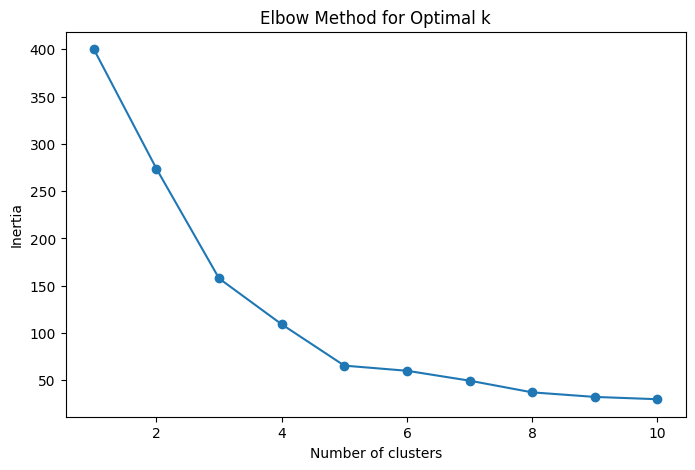

Optimal number of clusters (k): 5


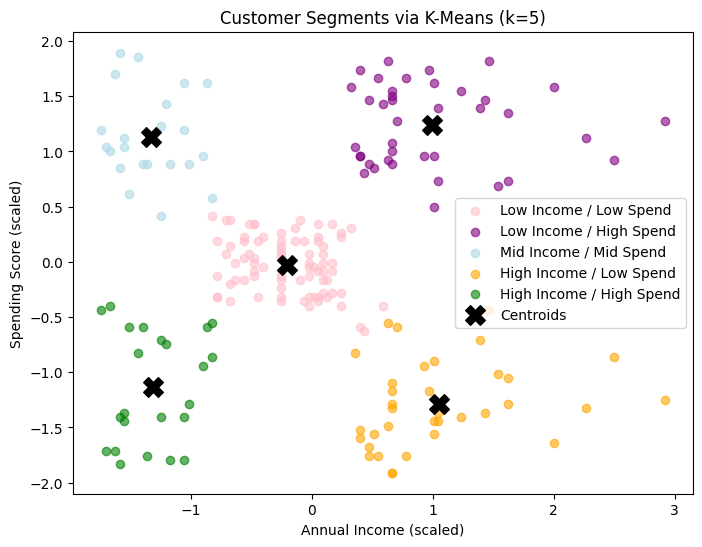


Cluster counts:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

Sample cluster assignments:
   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1                  15                      39        4
1           2                  15                      81        2
2           3                  16                       6        4
3           4                  16                      77        2
4           5                  17                      40        4
5           6                  17                      76        2
6           7                  18                       6        4
7           8                  18                      94        2
8           9                  19                       3        4
9          10                  19                      72        2

Cluster Profiling (average values):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

# 1. Load dataset
data = pd.read_csv("Mall_Customers.csv")

# 2. Select relevant features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
# 3. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# 5. Find optimal k using KneeLocator
knee = KneeLocator(K, inertia, curve="convex", direction="decreasing")
optimal_k = knee.knee
print(f"Optimal number of clusters (k): {optimal_k}")

# 6. Apply K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data['Cluster'] = clusters

# 7. Define cluster labels and colors (adjust based on interpretation)
cluster_labels = {
    0: "Low Income / Low Spend",
    1: "Low Income / High Spend",
    2: "Mid Income / Mid Spend",
    3: "High Income / Low Spend",
    4: "High Income / High Spend"
}
colors = ['pink', 'purple', 'lightblue', 'orange', 'green']

# 8. Visualize clusters with custom legend
plt.figure(figsize=(8,6))
for cluster_id, color in enumerate(colors):
    plt.scatter(X_scaled[clusters == cluster_id, 0], 
                X_scaled[clusters == cluster_id, 1], 
                c=color, label=cluster_labels.get(cluster_id, f"Cluster {cluster_id}"), alpha=0.6)

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            s=200, c='black', marker='X', label='Centroids')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title(f"Customer Segments via K-Means (k={optimal_k})")
plt.legend()
plt.show()

print("\nCluster counts:")
print(data['Cluster'].value_counts())

print("\nSample cluster assignments:")
print(data[['CustomerID','Annual Income (k$)','Spending Score (1-100)','Cluster']].head(10))


# 9. Cluster profiling (mean values per cluster)
profile = data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("\nCluster Profiling (average values):")
print(profile)